In [2]:
import pandas as pd

data = pd.read_csv("aml_syn_data")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484536 entries, 0 to 1484535
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Time_step           1484536 non-null  object 
 1   Label               1484536 non-null  object 
 2   Transaction_Id      1484536 non-null  object 
 3   Sender_Id           1119436 non-null  object 
 4   Sender_Account      1119436 non-null  object 
 5   Sender_Institution  1119436 non-null  object 
 6   Sender_Country      1119436 non-null  object 
 7   USD_amount          1484536 non-null  float64
 8   Bene_Id             1169913 non-null  object 
 9   Bene_Account        921185 non-null   object 
 10  Bene_Institution    921185 non-null   object 
 11  Bene_Country        921185 non-null   object 
 12  Transaction_Type    1484536 non-null  object 
dtypes: float64(1), object(12)
memory usage: 147.2+ MB


In [8]:
data2 = data[['Time_step',"Label","Transaction_Id","USD_amount","Transaction_Type"]]
data2.drop_duplicates(subset="Transaction_Id")
data2["Time_step"] = pd.to_datetime(data2["Time_step"],format='%Y-%m-%d %H:%M:%S')

/var/folders/qw/shwwmm4x2fd28l5kzqkky1mm0000gn/T/ipykernel_77489/4134607545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2["Time_step"] = pd.to_datetime(data2["Time_step"],format='%Y-%m-%d %H:%M:%S')


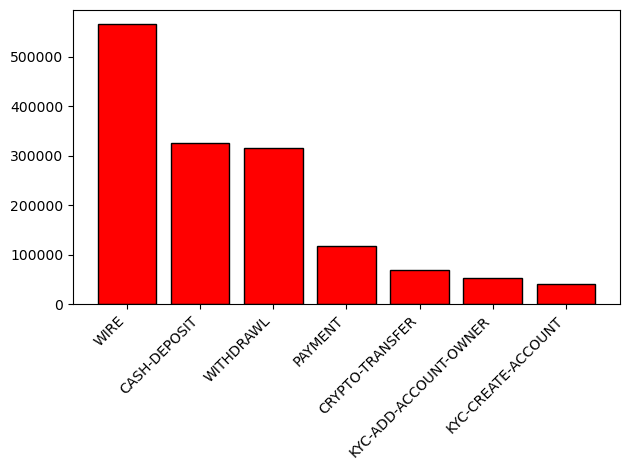

In [16]:
import matplotlib.pyplot as plt

frequency_counts = data2["Transaction_Type"].value_counts()
plt.bar(frequency_counts.index,frequency_counts.values,color="red",edgecolor="black")
plt.xticks(rotation=45, ha='right')  # rotate 45° and align right
plt.tight_layout()  # adjust spacing so labels fit
plt.show()

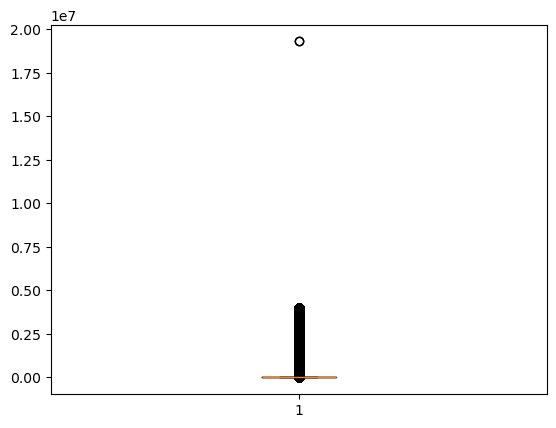

In [17]:
plt.boxplot(data2["USD_amount"])
plt.show()

(array([1.274406e+06, 1.288430e+05, 5.816600e+04, 3.168000e+03,
        3.120000e+03, 3.131000e+03, 3.175000e+03, 3.156000e+03,
        3.201000e+03, 3.102000e+03, 1.066000e+03, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 2.000000e+00]),
 array([       0.  ,   386000.02,   772000.04,  1158000.06,  1544000.08,
         1930000.1 ,  2316000.12,  2702000.14,  3088000.16,  3474000.18,
         3860000.2 ,  4246000.22,  4632000.24,  

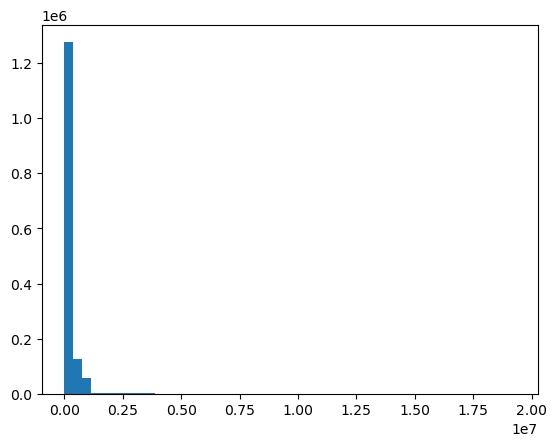

In [20]:
plt.hist(data2["USD_amount"],bins=50)


In [21]:
data["Sender_Id"].head(20)

0          JPMC-CLIENT-174571-02
1          JPMC-CLIENT-105413-03
2              COMPANY-235572-04
3          JPMC-CLIENT-379064-02
4          JPMC-CLIENT-413218-04
5              COMPANY-256174-02
6              COMPANY-483228-04
7     BILLING-COMPANY-1718175-04
8          JPMC-CLIENT-291195-06
9             COMPANY-1129922-06
10                           NaN
11     BILLING-COMPANY-497986-04
12        JPMC-CLIENT-1913045-04
13            CUSTOMER-623641-06
14      BILLING-COMPANY-63463-02
15          JPMC-CLIENT-78525-04
16     BILLING-COMPANY-108229-04
17    BILLING-COMPANY-1177173-04
18        JPMC-CLIENT-2534930-04
19            COMPANY-1220283-06
Name: Sender_Id, dtype: object

In [24]:
data['Category'] = data['Sender_Id'].str.extract(r'([A-Z-]+)')
data['Category'].head()

0    JPMC-CLIENT-
1    JPMC-CLIENT-
2        COMPANY-
3    JPMC-CLIENT-
4    JPMC-CLIENT-
Name: Category, dtype: object

In [25]:
data['Category'].nunique()


7

In [26]:
data['Category'].unique()

array(['JPMC-CLIENT-', 'COMPANY-', 'BILLING-COMPANY-', nan, 'CUSTOMER-',
       'STANDARD-COMPANY-', 'JPMC-BILLING-COMPANY-',
       'JPMC-STANDARD-COMPANY-'], dtype=object)

In [27]:
data.head()

,Time_step,Label,Transaction_Id,Sender_Id,Sender_Account,Sender_Institution,Sender_Country,USD_amount,Bene_Id,Bene_Account,Bene_Institution,Bene_Country,Transaction_Type,Category
0,2022-01-07 00:02:00,GOOD,T-174791-02,JPMC-CLIENT-174571-02,CHECKING-174582-02,JPMORGANCHASE,USA,0.00,CUSTOMER-174577-02,CHECKING-174582-02,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER,JPMC-CLIENT-
1,2022-01-07 00:02:00,GOOD,T-105637-03,JPMC-CLIENT-105413-03,CHECKING-105426-03,JPMORGANCHASE,USA,0.00,CUSTOMER-105419-03,CHECKING-105426-03,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER,JPMC-CLIENT-
2,2022-01-07 00:02:00,GOOD,T-235858-04,COMPANY-235572-04,CHECKING-235577-04,JPMORGANCHASE,USA,0.00,JPMC-CLIENT-235567-04,CHECKING-235577-04,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER,COMPANY-
3,2022-01-07 00:02:00,GOOD,T-379320-02,JPMC-CLIENT-379064-02,CHECKING-379071-02,BANK-379167-02,USA,68.35,OWNER-379114-02,CHECKING-379117-02,JPMORGANCHASE,USA,WIRE,JPMC-CLIENT-
4,2022-01-07 00:02:00,GOOD,T-413316-04,JPMC-CLIENT-413218-04,CHECKING-413226-04,JPMORGANCHASE,USA,0.00,CUSTOMER-413224-04,CHECKING-413226-04,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER,JPMC-CLIENT-


In [28]:
# Get the list of all current columns
cols = list(data.columns)

# Remove 'Category' from wherever it is now
cols.remove('Category')

# Find the index of 'Sender_Id' (the column you want to place it after)
sender_index = cols.index('Sender_Id')

# Insert 'Category' right after 'Sender_Id'
cols.insert(sender_index + 1, 'Category')

# Reorder the DataFrame
data = data[cols]


In [29]:
data.head()

,Time_step,Label,Transaction_Id,Sender_Id,Category,Sender_Account,Sender_Institution,Sender_Country,USD_amount,Bene_Id,Bene_Account,Bene_Institution,Bene_Country,Transaction_Type
0,2022-01-07 00:02:00,GOOD,T-174791-02,JPMC-CLIENT-174571-02,JPMC-CLIENT-,CHECKING-174582-02,JPMORGANCHASE,USA,0.00,CUSTOMER-174577-02,CHECKING-174582-02,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER
1,2022-01-07 00:02:00,GOOD,T-105637-03,JPMC-CLIENT-105413-03,JPMC-CLIENT-,CHECKING-105426-03,JPMORGANCHASE,USA,0.00,CUSTOMER-105419-03,CHECKING-105426-03,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER
2,2022-01-07 00:02:00,GOOD,T-235858-04,COMPANY-235572-04,COMPANY-,CHECKING-235577-04,JPMORGANCHASE,USA,0.00,JPMC-CLIENT-235567-04,CHECKING-235577-04,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER
3,2022-01-07 00:02:00,GOOD,T-379320-02,JPMC-CLIENT-379064-02,JPMC-CLIENT-,CHECKING-379071-02,BANK-379167-02,USA,68.35,OWNER-379114-02,CHECKING-379117-02,JPMORGANCHASE,USA,WIRE
4,2022-01-07 00:02:00,GOOD,T-413316-04,JPMC-CLIENT-413218-04,JPMC-CLIENT-,CHECKING-413226-04,JPMORGANCHASE,USA,0.00,CUSTOMER-413224-04,CHECKING-413226-04,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER


In [30]:
data.insert(10,'Bene_Category',data['Bene_Id'].str.extract(r'([A-Z-]+)'))

In [31]:
data.head()

,Time_step,Label,Transaction_Id,Sender_Id,Category,Sender_Account,Sender_Institution,Sender_Country,USD_amount,Bene_Id,Bene_Category,Bene_Account,Bene_Institution,Bene_Country,Transaction_Type
0,2022-01-07 00:02:00,GOOD,T-174791-02,JPMC-CLIENT-174571-02,JPMC-CLIENT-,CHECKING-174582-02,JPMORGANCHASE,USA,0.00,CUSTOMER-174577-02,CUSTOMER-,CHECKING-174582-02,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER
1,2022-01-07 00:02:00,GOOD,T-105637-03,JPMC-CLIENT-105413-03,JPMC-CLIENT-,CHECKING-105426-03,JPMORGANCHASE,USA,0.00,CUSTOMER-105419-03,CUSTOMER-,CHECKING-105426-03,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER
2,2022-01-07 00:02:00,GOOD,T-235858-04,COMPANY-235572-04,COMPANY-,CHECKING-235577-04,JPMORGANCHASE,USA,0.00,JPMC-CLIENT-235567-04,JPMC-CLIENT-,CHECKING-235577-04,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER
3,2022-01-07 00:02:00,GOOD,T-379320-02,JPMC-CLIENT-379064-02,JPMC-CLIENT-,CHECKING-379071-02,BANK-379167-02,USA,68.35,OWNER-379114-02,OWNER-,CHECKING-379117-02,JPMORGANCHASE,USA,WIRE
4,2022-01-07 00:02:00,GOOD,T-413316-04,JPMC-CLIENT-413218-04,JPMC-CLIENT-,CHECKING-413226-04,JPMORGANCHASE,USA,0.00,CUSTOMER-413224-04,CUSTOMER-,CHECKING-413226-04,JPMORGANCHASE,USA,KYC-ADD-ACCOUNT-OWNER


In [32]:
data['Bene_Category'].unique()

array(['CUSTOMER-', 'JPMC-CLIENT-', 'OWNER-', 'CHECKING-',
       'BILLING-COMPANY-', 'COMPANY-', 'JPMC-BILLING-COMPANY-', nan,
       'JPMC-CUSTOMER-', 'STANDARD-COMPANY-'], dtype=object)

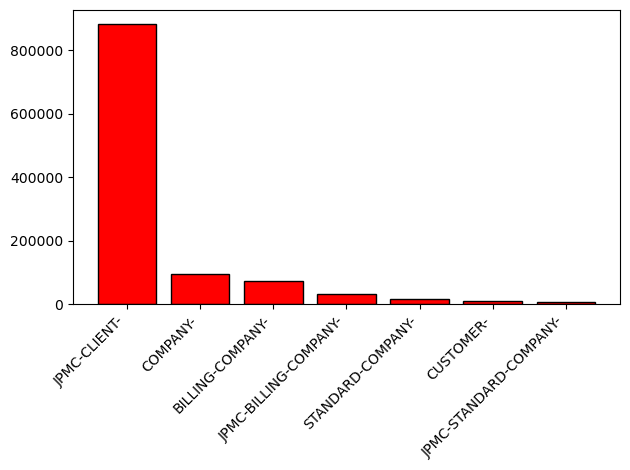

In [33]:
import matplotlib.pyplot as plt

frequency_counts = data["Category"].value_counts()
plt.bar(frequency_counts.index,frequency_counts.values,color="red",edgecolor="black")
plt.xticks(rotation=45, ha='right')  # rotate 45° and align right
plt.tight_layout()  # adjust spacing so labels fit
plt.show()

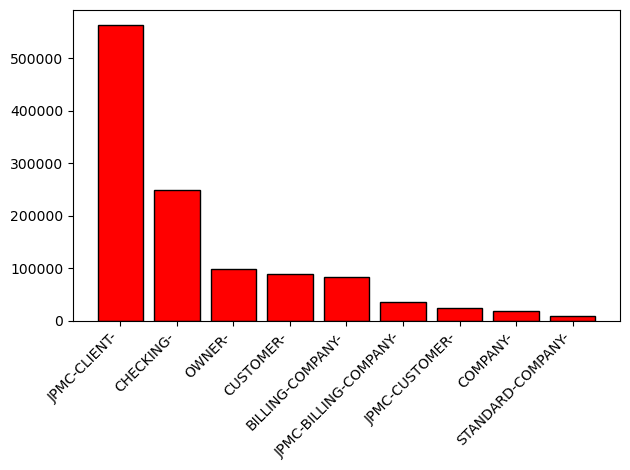

In [34]:
import matplotlib.pyplot as plt

frequency_counts = data["Bene_Category"].value_counts()
plt.bar(frequency_counts.index,frequency_counts.values,color="red",edgecolor="black")
plt.xticks(rotation=45, ha='right')  # rotate 45° and align right
plt.tight_layout()  # adjust spacing so labels fit
plt.show()

In [36]:
data.loc[:,'Label_encoded'] = data['Label'].map({'GOOD': 1, 'BAD': 0})


Category
BILLING-COMPANY-          1.000000
COMPANY-                  0.806278
CUSTOMER-                 1.000000
JPMC-BILLING-COMPANY-     1.000000
JPMC-CLIENT-              0.807310
JPMC-STANDARD-COMPANY-    1.000000
STANDARD-COMPANY-         1.000000
Name: Label_encoded, dtype: float64


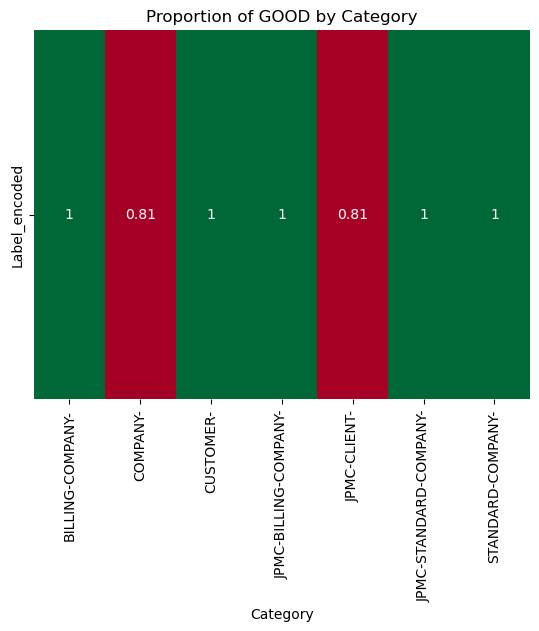

In [38]:
good_rate = data.groupby('Category')['Label_encoded'].mean()
print(good_rate)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(good_rate.to_frame().T, annot=True, cmap='RdYlGn', cbar=False)
plt.title('Proportion of GOOD by Category')
plt.show()


In [43]:

# Parse time
data["Time_step"] = pd.to_datetime(data["Time_step"])

# Map accounts to node indices
all_accounts = pd.unique(
    pd.concat([data["Sender_Account"], data["Bene_Account"]], ignore_index=True)
)
acct2idx = {acct: i for i, acct in enumerate(all_accounts)}

data["src"] = data["Sender_Account"].map(acct2idx)
data["dst"] = data["Bene_Account"].map(acct2idx)


In [44]:
data = data.sort_values("Time_step").reset_index(drop=True)
n = len(data)

train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_df = data.iloc[:train_end]
val_df   = data.iloc[train_end:val_end]
test_df  = data.iloc[val_end:]

In [47]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Log-scale amount
data["log_amount"] = np.log1p(data["USD_amount"])

# Time features
data["hour"] = data["Time_step"].dt.hour
data["dayofweek"] = data["Time_step"].dt.dayofweek
data["month"] = data["Time_step"].dt.month

# Normalize continuous features (fit on train only)
cont_edge_cols = ["log_amount", "hour", "dayofweek", "month"]
scaler = StandardScaler()
data[cont_edge_cols] = scaler.fit_transform(data[cont_edge_cols])

# Categorical edge features (transaction type)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
tx_type_ohe = ohe.fit_transform(data[["Transaction_Type"]])

# Assemble edge_attr matrix
import numpy as np

edge_cont = data[cont_edge_cols].to_numpy()
edge_attr = np.hstack([edge_cont, tx_type_ohe])

# Store edge_attr indices per split
edge_attr_train = edge_attr[train_df.index]
edge_attr_val   = edge_attr[val_df.index]
edge_attr_test  = edge_attr[test_df.index]


In [48]:
label_map = {"GOOD": 0, "BAD": 1}
data["y"] = data["Label"].map(label_map)

y_train = data.loc[train_df.index, "y"].to_numpy()
y_val   = data.loc[val_df.index, "y"].to_numpy()
y_test  = data.loc[test_df.index, "y"].to_numpy()


In [49]:
# Build basic per-account stats using all data
sent_stats = data.groupby("src").agg(
    sent_count=("src", "size"),
    sent_total_amount=("USD_amount", "sum"),
    sent_avg_amount=("USD_amount", "mean"),
)

recv_stats = data.groupby("dst").agg(
    recv_count=("dst", "size"),
    recv_total_amount=("USD_amount", "sum"),
    recv_avg_amount=("USD_amount", "mean"),
)

node_stats = sent_stats.join(recv_stats, how="outer").fillna(0.0)

# Normalize numeric node features
from sklearn.preprocessing import StandardScaler

node_scaler = StandardScaler()
node_features = node_scaler.fit_transform(node_stats.values)

# Make sure rows are aligned with node indices
# node_stats index is src/dst index (0..num_nodes-1) because we used src/dst integer IDs
num_nodes = len(all_accounts)
assert node_stats.shape[0] <= num_nodes


In [50]:
data.head()

,Time_step,Label,Transaction_Id,Sender_Id,Category,Sender_Account,Sender_Institution,Sender_Country,USD_amount,Bene_Id,...,Bene_Country,Transaction_Type,Label_encoded,src,dst,log_amount,hour,dayofweek,month,y
0,2022-01-07 00:02:00,GOOD,T-174791-02,JPMC-CLIENT-174571-02,JPMC-CLIENT-,CHECKING-174582-02,JPMORGANCHASE,USA,0.00,CUSTOMER-174577-02,...,USA,KYC-ADD-ACCOUNT-OWNER,1,0,0,-2.492505,-1.657544,0.50901,-1.763072,0
1,2022-01-07 00:02:00,GOOD,T-498146-04,BILLING-COMPANY-497986-04,BILLING-COMPANY-,CHECKING-497984-04,BANK-498147-04,USA,2356.79,JPMC-CLIENT-497983-04,...,USA,WIRE,1,11,34270,-0.128428,-1.657544,0.50901,-1.763072,0
2,2022-01-07 00:02:00,GOOD,T-824056-10,NaN,NaN,NaN,NaN,NaN,0.00,CUSTOMER-823856-10,...,CANADA,KYC-CREATE-ACCOUNT,1,10,53396,-2.492505,-1.657544,0.50901,-1.763072,0
3,2022-01-07 00:02:00,GOOD,T-291469-06,JPMC-CLIENT-291195-06,JPMC-CLIENT-,CHECKING-291203-06,JPMORGANCHASE,USA,5224.67,CHECKING-291207-06,...,NaN,WIRE,1,8,10,0.113858,-1.657544,0.50901,-1.763072,0
4,2022-01-07 00:02:00,GOOD,T-1718316-04,BILLING-COMPANY-1718175-04,BILLING-COMPANY-,CHECKING-1718173-04,BANK-1718317-04,USA,5249.97,JPMC-CLIENT-1718172-04,...,USA,WIRE,1,7,43753,0.115328,-1.657544,0.50901,-1.763072,0


In [52]:
import numpy as np

def most_frequent_or_nan(x):
    vc = x.value_counts(dropna=True)
    if vc.empty:
        return np.nan
    return vc.index[0]

# Dominant sender country per account (by src)
dom_country = (
    data.groupby("src")["Sender_Country"]
        .agg(most_frequent_or_nan)
        .reindex(range(num_nodes))  # ensure index 0..num_nodes-1
)

# Optionally fill unknowns
dom_country = dom_country.fillna("UNKNOWN")

from sklearn.preprocessing import OneHotEncoder

ohe_country = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
country_ohe = ohe_country.fit_transform(dom_country.to_frame())

# Concatenate with your numeric node_stats features
node_features = np.hstack([node_stats.values, country_ohe])



In [56]:
import torch
from torch_geometric.data import Data

# Edge index (all edges)
edge_index = torch.as_tensor(
    np.vstack([data["src"].to_numpy(), data["dst"].to_numpy()]),
    dtype=torch.long
)

x = torch.tensor(node_features, dtype=torch.float)
edge_attr_t = torch.tensor(edge_attr, dtype=torch.float)
y = torch.tensor(data["y"].to_numpy(), dtype=torch.float)

data2 = Data(
    x=x,
    edge_index=edge_index,
    edge_attr=edge_attr_t
)

# Edge masks for splits
train_mask = torch.zeros(edge_index.size(1), dtype=torch.bool)
val_mask   = torch.zeros(edge_index.size(1), dtype=torch.bool)
test_mask  = torch.zeros(edge_index.size(1), dtype=torch.bool)

train_mask[train_df.index] = True
val_mask[val_df.index] = True
test_mask[test_df.index] = True

data2.train_mask = train_mask
data2.val_mask   = val_mask
data2.test_mask  = test_mask
data2.y          = y  # edge-level labels


In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class EdgeClassifierGNN(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, hidden_dim=64):
        super().__init__()
        self.conv1 = SAGEConv(node_in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # binary logit
        )

    def forward(self, x, edge_index, edge_attr):
        # Node embedding
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        src, dst = edge_index
        h_src = x[src]
        h_dst = x[dst]

        edge_repr = torch.cat([h_src, h_dst, edge_attr], dim=-1)
        logit = self.edge_mlp(edge_repr).squeeze(-1)  # [num_edges]

        return logit


In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EdgeClassifierGNN(
    node_in_dim=data2.x.size(1),
    edge_in_dim=data2.edge_attr.size(1),
    hidden_dim=64
).to(device)

data2 = data2.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0], device=device))  # adjust for imbalance

for epoch in range(1, 51):
    model.train()
    optimizer.zero_grad()

    logits = model(data2.x, data2.edge_index, data2.edge_attr)
    loss = criterion(logits[data2.train_mask], data2.y[data2.train_mask])

    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_logits = logits[data2.val_mask]
        val_probs = torch.sigmoid(val_logits)
        val_preds = (val_probs > 0.5).float()
        val_labels = data2.y[data2.val_mask]

        # simple metrics
        from sklearn.metrics import f1_score
        f1 = f1_score(val_labels.cpu(), val_preds.cpu())

    print(f"Epoch {epoch} | train_loss={loss.item():.4f} | val_f1={f1:.4f}")


Epoch 1 | train_loss=667585280.0000 | val_f1=0.0000
Epoch 2 | train_loss=198669712.0000 | val_f1=0.0084
Epoch 3 | train_loss=79511968.0000 | val_f1=0.5976
Epoch 4 | train_loss=190409904.0000 | val_f1=0.4602
Epoch 5 | train_loss=216055152.0000 | val_f1=0.4604
Epoch 6 | train_loss=190342128.0000 | val_f1=0.4602
Epoch 7 | train_loss=155881824.0000 | val_f1=0.6478
Epoch 8 | train_loss=158680672.0000 | val_f1=0.6195
Epoch 9 | train_loss=151481440.0000 | val_f1=0.6017
Epoch 10 | train_loss=131214192.0000 | val_f1=0.6022
Epoch 11 | train_loss=101459168.0000 | val_f1=0.6158
Epoch 12 | train_loss=67913720.0000 | val_f1=0.6460
Epoch 13 | train_loss=48194764.0000 | val_f1=0.5121
Epoch 14 | train_loss=35716308.0000 | val_f1=0.4576
Epoch 15 | train_loss=37255996.0000 | val_f1=0.2924
Epoch 16 | train_loss=48506636.0000 | val_f1=0.3800
Epoch 17 | train_loss=38551872.0000 | val_f1=0.3773
Epoch 18 | train_loss=22350636.0000 | val_f1=0.5816
Epoch 19 | train_loss=25791118.0000 | val_f1=0.6203
Epoch 20 | 